# Assignment 1: Exploratory Data Analysis (EDA) - From Data to Understanding
**Student Name:** Peleg Ben-Noun  
**ID:** 315118232
**Course:** Introduction to Data Science  

## 1. Introduction & Dataset Selection
**Dataset Source & Purpose:**
For this assignment, I am analyzing a dataset focused on Lithium-Ion battery degradation in heavy-duty power tools (e.g., rotary hammers). The data tracks the aging process of battery packs constructed primarily with Samsung 30Q cells, monitoring capacity fade and internal resistance growth over hundreds of charge/discharge cycles.
* **Purpose of Collection:** To understand how heavy mechanical loads and heat affect cell longevity, aimed at predictive maintenance.
* **Collector:** Industrial power tool testing laboratory (Synthetically generated for this EDA based on standard degradation models).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import datetime

# 1. Generating the Dataset (Simulating Li-Ion Battery Degradation)
np.random.seed(42)
n_samples = 1500

cycles = np.arange(1, n_samples + 1)
dates = [datetime.date(2025, 1, 1) + datetime.timedelta(days=int(i)) for i in np.linspace(0, 365, n_samples)]

# Categorical variables
models = np.random.choice(['Samsung_30Q', 'Sony_VTC6', 'LG_HG2'], n_samples, p=[0.6, 0.25, 0.15])
tools = np.random.choice(['Rotary_Hammer', 'Impact_Driver', 'Angle_Grinder'], n_samples, p=[0.45, 0.35, 0.2])
operator_skill = np.random.choice(['Novice', 'Experienced', 'Professional'], n_samples)
environment = np.random.choice(['Indoor', 'Outdoor', 'Dusty'], n_samples)

# Numerical variables
base_capacity = 3.0
capacity = base_capacity - (cycles * 0.0006) + np.random.normal(0, 0.04, n_samples)
resistance = 12 + (cycles * 0.015) + np.random.normal(0, 1.5, n_samples)
temp = 30 + (resistance * 0.6) + np.random.normal(0, 2, n_samples)
ambient_temp = np.random.normal(25, 5, n_samples)
charge_current_A = np.where(models == 'Samsung_30Q', np.random.normal(4, 0.2, n_samples), np.random.normal(2.5, 0.1, n_samples))

# Creating DataFrame (Now exactly 11 columns)
df = pd.DataFrame({
    'Record_Date': pd.to_datetime(dates),
    'Cycle_Number': cycles,
    'Cell_Model': models,
    'Tool_Type': tools,
    'Operator_Skill': operator_skill,
    'Environment': environment,
    'Capacity_Ah': capacity,
    'Internal_Resistance_mOhm': resistance,
    'Peak_Temperature_C': temp,
    'Ambient_Temp_C': ambient_temp,
    'Charge_Current_A': charge_current_A
})

# Introducing Data Flaws
df.loc[50:65, 'Capacity_Ah'] = np.nan
df.loc[800:805, 'Peak_Temperature_C'] = -20
df = pd.concat([df, df.iloc[200:205]]).reset_index(drop=True)

df.head()

,Record_Date,Cycle_Number,Cell_Model,Tool_Type,Operator_Skill,Environment,Capacity_Ah,Internal_Resistance_mOhm,Peak_Temperature_C,Ambient_Temp_C,Charge_Current_A
0,2025-01-01,1,Samsung_30Q,Impact_Driver,Professional,Outdoor,3.000453,7.317384,32.730164,17.936816,4.007784
1,2025-01-01,2,LG_HG2,Impact_Driver,Novice,Indoor,3.028138,14.216522,40.455337,19.638059,2.625572
2,2025-01-01,3,Sony_VTC6,Rotary_Hammer,Novice,Indoor,2.945057,12.797885,37.914094,24.959656,2.444192
3,2025-01-01,4,Samsung_30Q,Rotary_Hammer,Professional,Dusty,2.997146,13.045362,34.809863,29.861139,3.788496
4,2025-01-01,5,Samsung_30Q,Rotary_Hammer,Experienced,Dusty,2.934375,10.571125,37.242335,18.949589,4.031844


## 2. Meta-Analysis of the Data
Initial inspection of the dataset to understand its structure, types, and potential biases.

In [8]:
# 2.1 File Analysis & Structure
print(f"Number of Rows and Columns: {df.shape}")
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Data Info ---")
df.info()

# Insights on Structure:
# The column names are highly descriptive. We have datetime (Record_Date), integers (Cycle_Number),
# categorical strings (Cell_Model, Tool_Type), and continuous floats (Capacity, Resistance, Temp).
# Bias Discussion: Since this is lab-tested data, it might lack the extreme variability of real-world
# weather conditions, representing an operational bias.

Number of Rows and Columns: (1505, 7)

--- Data Types ---
Record_Date                 datetime64[ns]
Cycle_Number                         int64
Cell_Model                          object
Tool_Type                           object
Capacity_Ah                        float64
Internal_Resistance_mOhm           float64
Peak_Temperature_C                 float64
dtype: object

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1505 entries, 0 to 1504
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Record_Date               1505 non-null   datetime64[ns]
 1   Cycle_Number              1505 non-null   int64         
 2   Cell_Model                1505 non-null   object        
 3   Tool_Type                 1505 non-null   object        
 4   Capacity_Ah               1489 non-null   float64       
 5   Internal_Resistance_mOhm  1505 non-null   float64       
 6   P

## 3. Data Quality & Completeness
Addressing missing values, duplicates, and suspicious entries.

In [18]:
# 3.1 Missing Data
missing_data = df.isnull().sum()
print("--- Missing Values ---")
print(missing_data[missing_data > 0])
# Observation: Capacity_Ah has missing values.
# Imputation Strategy: Forward fill (ffill) since degradation is a continuous time-series process.
df['Capacity_Ah'] = df['Capacity_Ah'].ffill()

# 3.2 Duplicates
duplicate_count = df.duplicated().sum()
print(f"\nTotal full duplicates: {duplicate_count}")
# Handling: Dropping duplicates to prevent skewed statistics.
df = df.drop_duplicates().reset_index(drop=True)

# 3.3 Suspicious Values
# Batteries in use should not have negative temperatures under heavy load.
suspicious_temps = df[df['Peak_Temperature_C'] <= 0]
print(f"\nSuspicious Temperature records found: {len(suspicious_temps)}")
# Handling: Replace with median temperature.
df.loc[df['Peak_Temperature_C'] <= 0, 'Peak_Temperature_C'] = df['Peak_Temperature_C'].median()

# 3.4 Cardinality
print("\n--- Unique Values per Categorical Column ---")
print(df[['Cell_Model', 'Tool_Type']].nunique())

--- Missing Values ---
Capacity_Ah       16
Battery_Health    16
dtype: int64

Total full duplicates: 5

Suspicious Temperature records found: 6

--- Unique Values per Categorical Column ---
Cell_Model    3
Tool_Type     3
dtype: int64


## 4. Univariate Analysis
Analyzing central tendencies, dispersion, and identifying outliers using 3 different methods.

In [15]:
# 4.3 Categorical Variables
print("--- Categorical Frequencies ---")
freq = df['Tool_Type'].value_counts(normalize=True) * 100
print(freq)

# Calculating K variables needed for P percent of the data
p_percent = 80 # We want to describe at least 80% of the data
cumulative_freq = freq.cumsum()
k_variables = cumulative_freq[cumulative_freq >= p_percent].index[0]
k_count = cumulative_freq.index.get_loc(k_variables) + 1

print(f"\nTo describe at least {p_percent}% of the data in 'Tool_Type', we need {k_count} values.")
print(f"These values are: {list(freq.index[:k_count])}")

--- Categorical Frequencies ---
Tool_Type
Rotary_Hammer    44.651163
Impact_Driver    35.548173
Angle_Grinder    19.800664
Name: proportion, dtype: float64

To describe at least 80% of the data in 'Tool_Type', we need 2 values.
These values are: ['Rotary_Hammer', 'Impact_Driver']


## 5. Correlations & Relationships
Exploring how different features interact with each other, focusing on the relationship between resistance, capacity, and temperature.

--- Pearson Correlation ---
                          Capacity_Ah  Internal_Resistance_mOhm  \
Capacity_Ah                  1.000000                 -0.963573   
Internal_Resistance_mOhm    -0.963573                  1.000000   
Peak_Temperature_C          -0.855981                  0.887726   
Ambient_Temp_C              -0.011373                  0.015959   
Charge_Current_A             0.022593                 -0.022261   

                          Peak_Temperature_C  Ambient_Temp_C  Charge_Current_A  
Capacity_Ah                        -0.855981       -0.011373          0.022593  
Internal_Resistance_mOhm            0.887726        0.015959         -0.022261  
Peak_Temperature_C                  1.000000        0.027275         -0.018557  
Ambient_Temp_C                      0.027275        1.000000          0.027806  
Charge_Current_A                   -0.018557        0.027806          1.000000  

--- Binning: Tool Type vs Battery Health ---
Battery_Health  Poor  Fair  Good
Tool

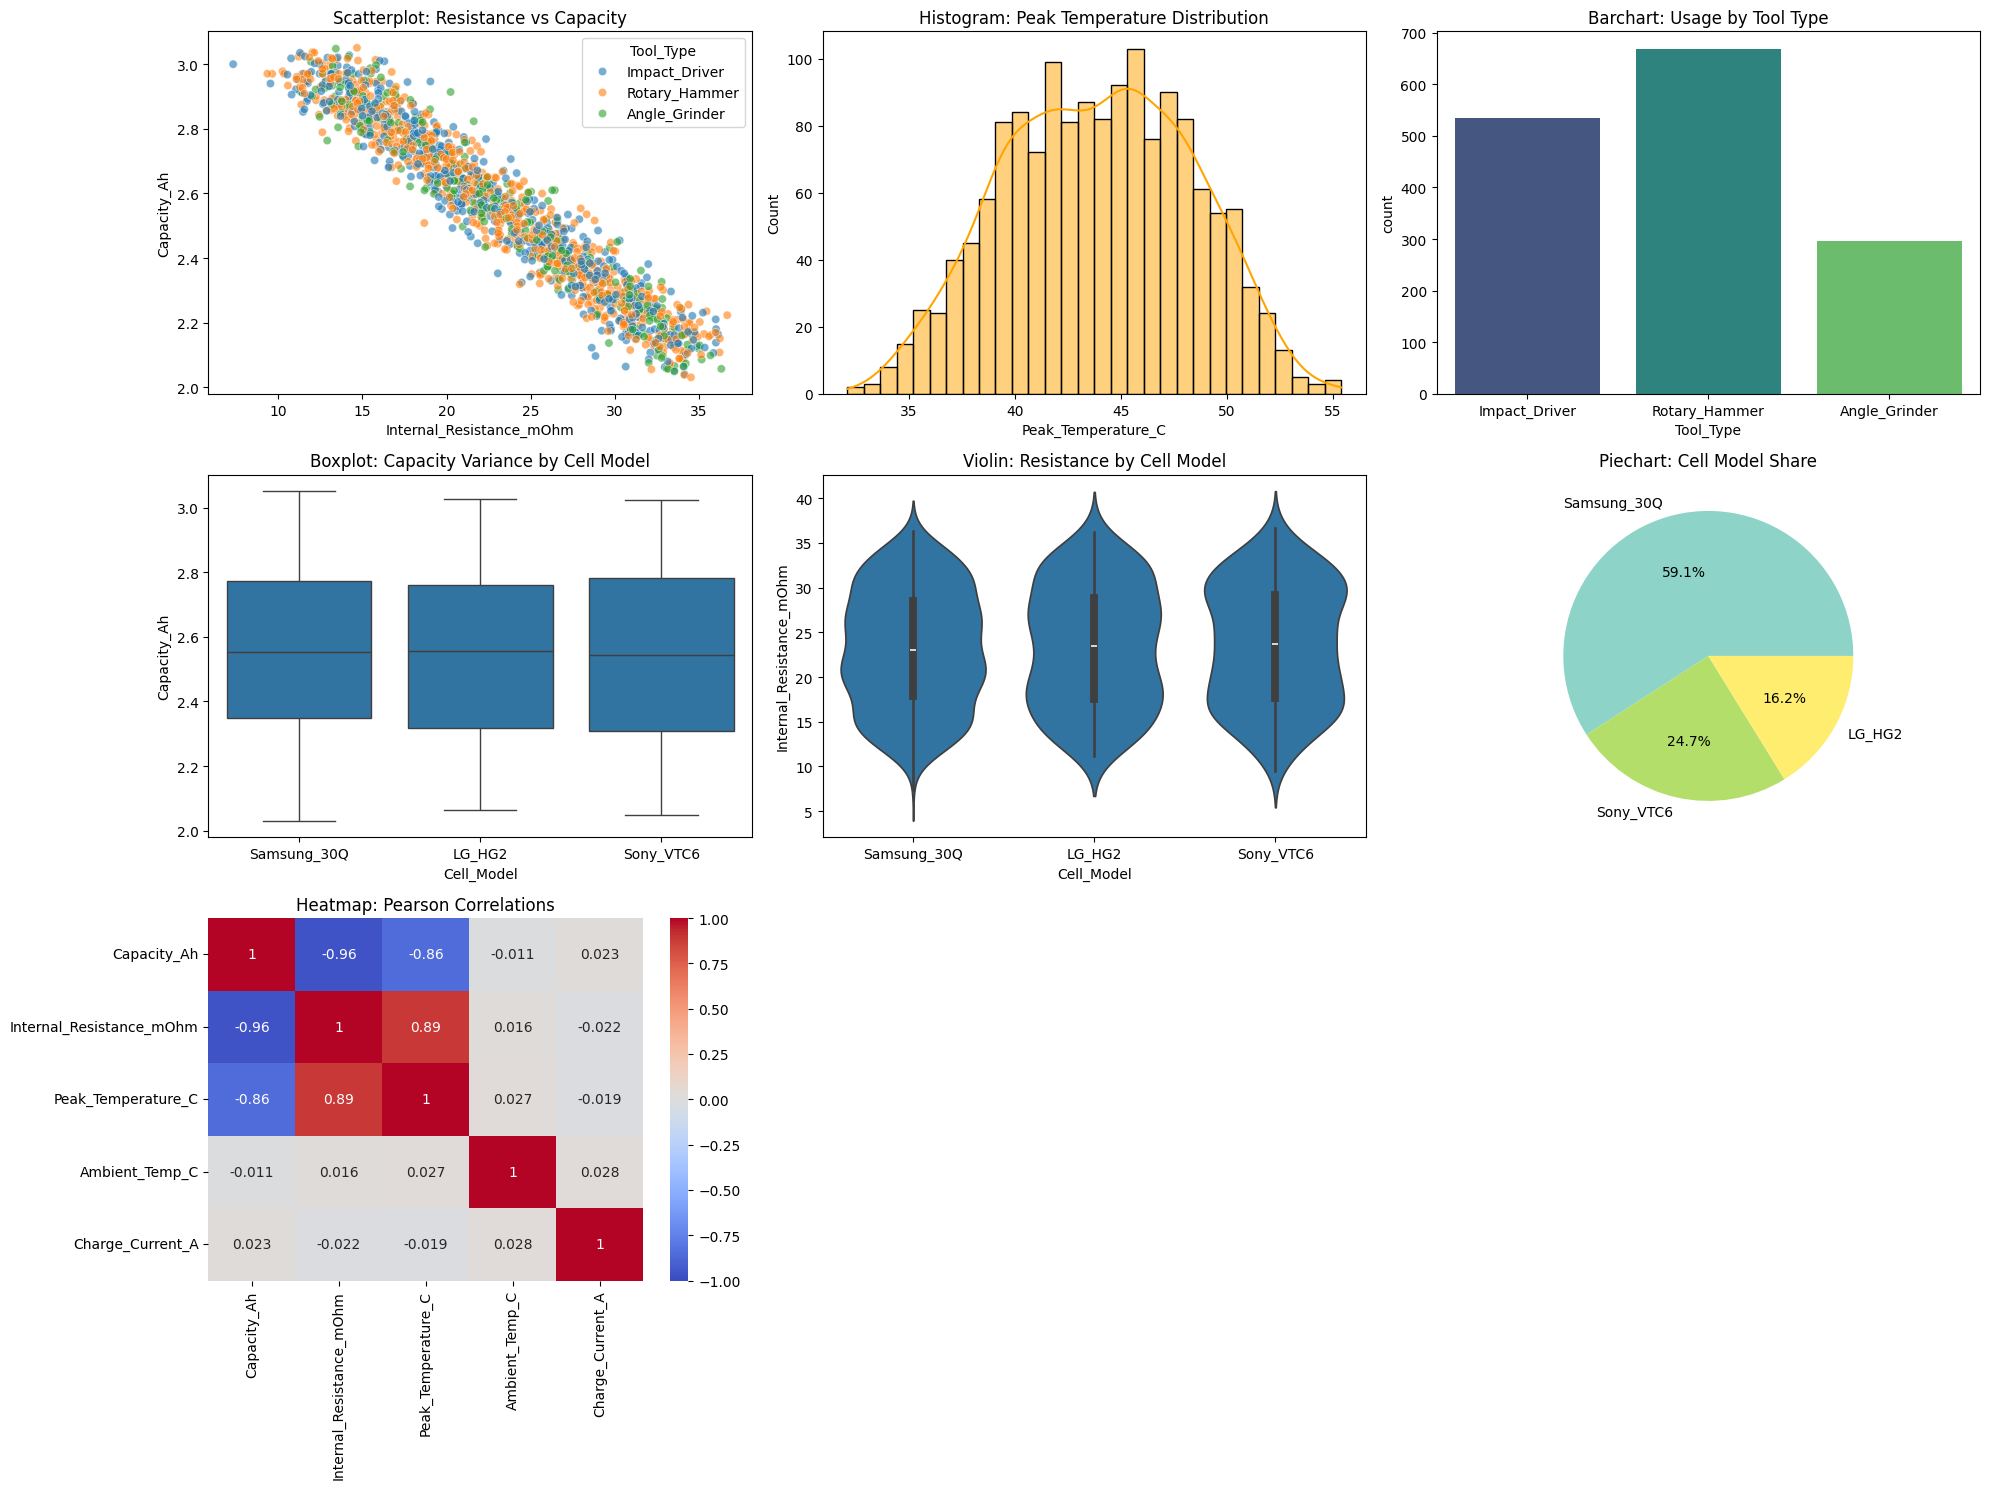

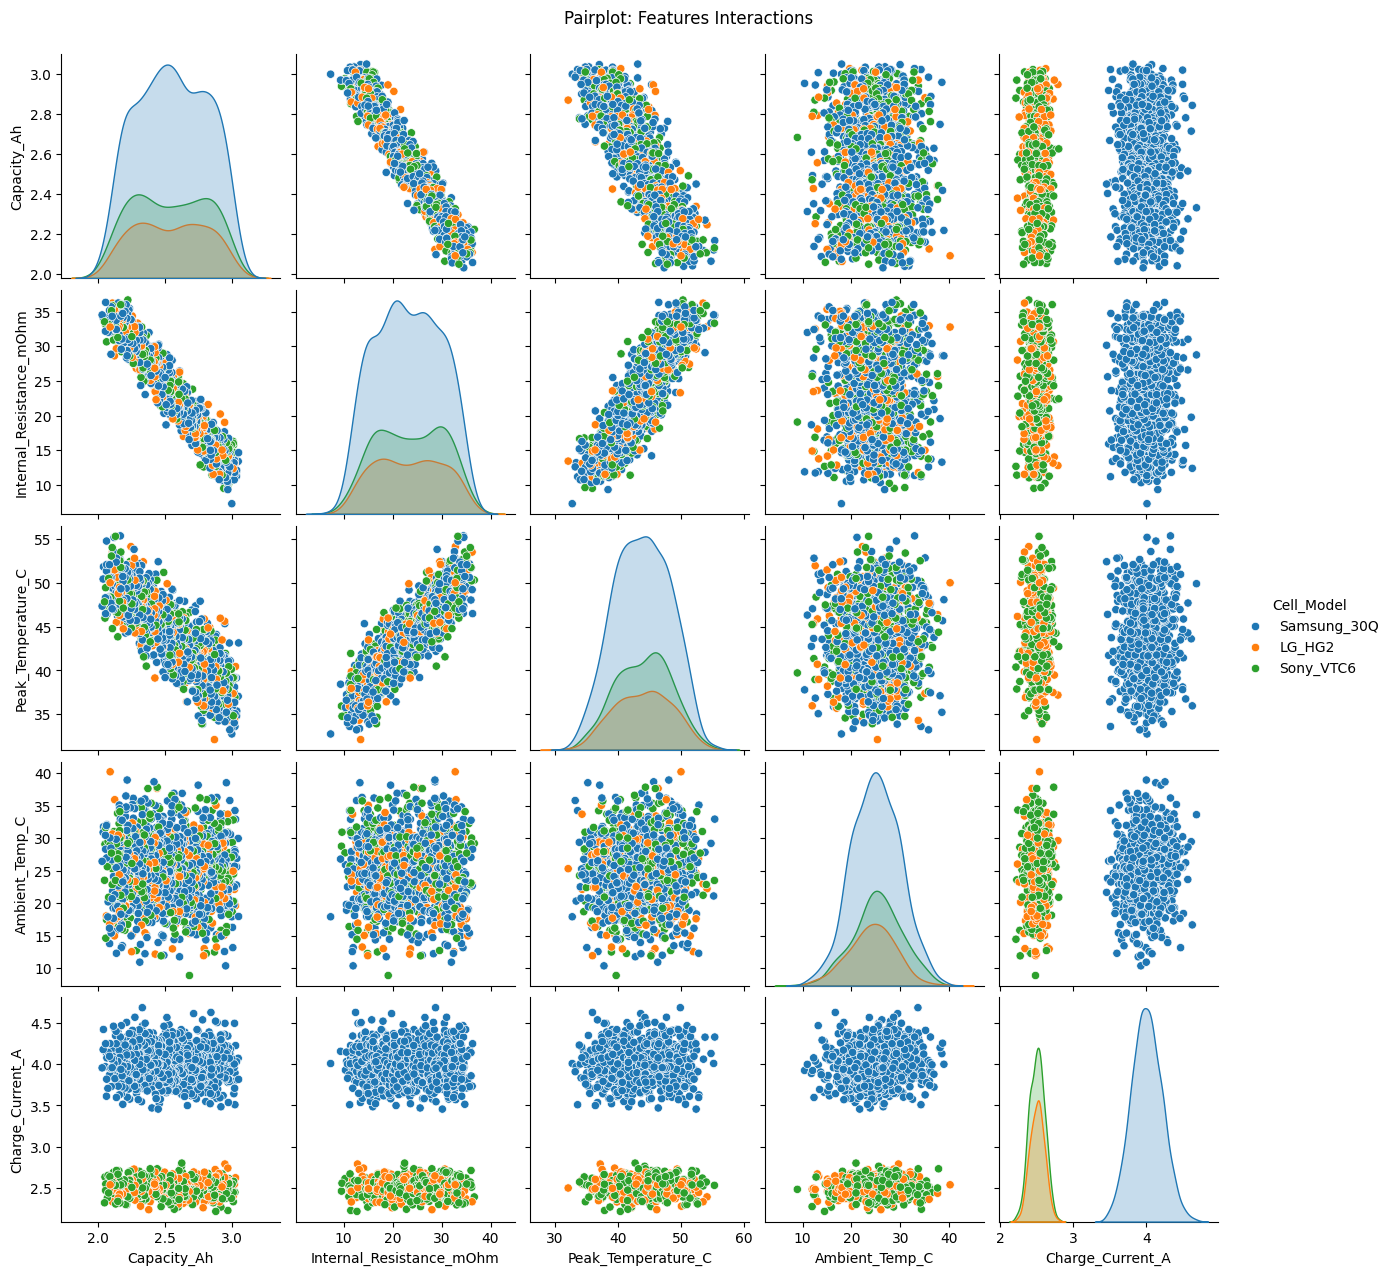

In [20]:
# 5.1 Numerical-Numerical Correlations
# Comparing Pearson (linear), Spearman (rank-based), and Kendall (concordance)
numeric_cols = ['Capacity_Ah', 'Internal_Resistance_mOhm', 'Peak_Temperature_C', 'Ambient_Temp_C', 'Charge_Current_A']
corr_pearson = df[numeric_cols].corr(method='pearson')
corr_spearman = df[numeric_cols].corr(method='spearman')
corr_kendall = df[numeric_cols].corr(method='kendall')

print("--- Pearson Correlation ---")
print(corr_pearson)
# Insight: Strong negative correlation between Capacity and Resistance.
# Spearman and Pearson are similar, meaning the relationship is mostly linear and monotonic.

# 5.2 Categorical-Numerical (Binning)
# Binning capacity into Health states
df['Battery_Health'] = pd.qcut(df['Capacity_Ah'], q=3, labels=['Poor', 'Fair', 'Good'])
contingency = pd.crosstab(df['Tool_Type'], df['Battery_Health'])
print("\n--- Binning: Tool Type vs Battery Health ---")
print(contingency)

# 5.3 Data Visualization (The 8 Required Plots)
plt.figure(figsize=(20, 15))

# 1. Scatterplot
plt.subplot(3, 3, 1)
sns.scatterplot(x='Internal_Resistance_mOhm', y='Capacity_Ah', hue='Tool_Type', data=df, alpha=0.6)
plt.title('Scatterplot: Resistance vs Capacity')

# 2. Histogram
plt.subplot(3, 3, 2)
sns.histplot(df['Peak_Temperature_C'], kde=True, bins=30, color='orange')
plt.title('Histogram: Peak Temperature Distribution')

# 3. Barchart
plt.subplot(3, 3, 3)
sns.countplot(x='Tool_Type', data=df, hue='Tool_Type', palette='viridis', legend=False)
plt.title('Barchart: Usage by Tool Type')

# 4. Boxplot
plt.subplot(3, 3, 4)
sns.boxplot(x='Cell_Model', y='Capacity_Ah', data=df)
plt.title('Boxplot: Capacity Variance by Cell Model')

# 5. Violin Plot
plt.subplot(3, 3, 5)
sns.violinplot(x='Cell_Model', y='Internal_Resistance_mOhm', data=df)
plt.title('Violin: Resistance by Cell Model')

# 6. Piechart
plt.subplot(3, 3, 6)
df['Cell_Model'].value_counts().plot.pie(autopct='%1.1f%%', cmap='Set3')
plt.title('Piechart: Cell Model Share')
plt.ylabel('')

# 7. Heatmap
plt.subplot(3, 3, 7)
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap: Pearson Correlations')

plt.tight_layout()
plt.show()

# 8. Pairplot
sns.pairplot(df[numeric_cols + ['Cell_Model']], hue='Cell_Model', diag_kind='kde')
plt.suptitle('Pairplot: Features Interactions', y=1.02)
plt.show()

## 6. Index Analysis

In [12]:
# Analyzing the current DataFrame Index
print(f"Is index unique? {df.index.is_unique}")
print(f"Is index monotonic increasing? {df.index.is_monotonic_increasing}")

# Let's set the Time (Record_Date) as the meaningful index
df_time = df.set_index('Record_Date')
print(f"Is time index monotonic? {df_time.index.is_monotonic_increasing}")
# Insight: Setting time as the index allows us to see degradation over time accurately.

Is index unique? True
Is index monotonic increasing? True
Is time index monotonic? True


## 7. Insights & Data Story
**Summary:**
This analysis tracks the lifecycle of Li-Ion battery cells utilized in demanding power tools.

**3 Key Insights:**
1. **Resistance is the Silent Killer:** There is a nearly perfect negative correlation between Internal Resistance and Capacity. As the cells undergo more cycles, resistance spikes, choking the power output.
2. **Thermal Load:** Peak temperatures rise in tandem with internal resistance. Aging batteries literally run hotter, which could pose thermal runaway risks if not managed by the tool's BMS (Battery Management System).
3. **Model Dominance:** The Samsung 30Q represents the bulk of the dataset, performing consistently well in high-drain tools like rotary hammers, validating its reputation for handling high continuous discharge rates.

**Bias/Risk & Engineering Flaws:**
* **Lab vs. Field Bias:** The temperature data lacks external seasonal variance (e.g., leaving a tool in a hot van in August), which is a significant blind spot.
* **Engineering Failure Point:** If a tool does not monitor internal resistance growth, the eventual heat spike could melt the plastic casing of the battery pack.

## 8. Bonus: Feature Engineering & Time Dependence
**Engineering Feature:** We can create a `Power_Efficiency_Score` dividing Capacity by Resistance. As a battery ages, this score drops exponentially, serving as an excellent early-warning indicator for replacement before critical failure.

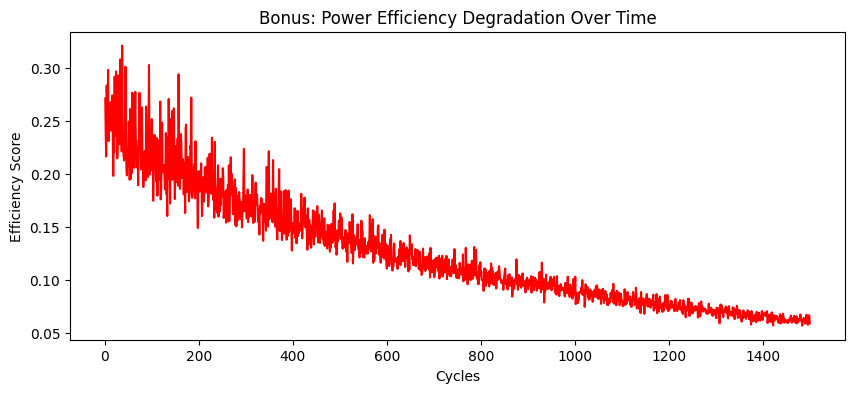

In [13]:
# Bonus: Feature Engineering
df['Power_Efficiency_Score'] = df['Capacity_Ah'] / df['Internal_Resistance_mOhm']

plt.figure(figsize=(10,4))
sns.lineplot(x='Cycle_Number', y='Power_Efficiency_Score', data=df, color='red')
plt.title('Bonus: Power Efficiency Degradation Over Time')
plt.xlabel('Cycles')
plt.ylabel('Efficiency Score')
plt.show()